In [1]:
!pip install pandas numpy nltk scikit-learn matplotlib seaborn wordcloud

In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [4]:
data = {
    'review': [
        "Food was delicious and delivery was fast",
        "Packaging was poor and food was cold",
        "Excellent taste and amazing customer service",
        "Delivery took too long and food was bad",
        "Prices are too expensive for the quantity",
        "Loved the pizza and quick delivery",
        "Customer support was rude",
        "Food quality was excellent",
        "Late delivery ruined the experience",
        "Very tasty food and good packaging",
        "Bad service and expensive menu",
        "I really enjoyed the meal"
    ],

    'sentiment': [
        'Positive',
        'Negative',
        'Positive',
        'Negative',
        'Negative',
        'Positive',
        'Negative',
        'Positive',
        'Negative',
        'Positive',
        'Negative',
        'Positive'
    ]
}

df = pd.DataFrame(data)

df.to_csv("restaurant_reviews.csv", index=False)

print(df)

                                          review sentiment
0       Food was delicious and delivery was fast  Positive
1           Packaging was poor and food was cold  Negative
2   Excellent taste and amazing customer service  Positive
3        Delivery took too long and food was bad  Negative
4      Prices are too expensive for the quantity  Negative
5             Loved the pizza and quick delivery  Positive
6                      Customer support was rude  Negative
7                     Food quality was excellent  Positive
8            Late delivery ruined the experience  Negative
9             Very tasty food and good packaging  Positive
10                Bad service and expensive menu  Negative
11                     I really enjoyed the meal  Positive


In [5]:
df = pd.read_csv("restaurant_reviews.csv")

print(df.head())

                                         review sentiment
0      Food was delicious and delivery was fast  Positive
1          Packaging was poor and food was cold  Negative
2  Excellent taste and amazing customer service  Positive
3       Delivery took too long and food was bad  Negative
4     Prices are too expensive for the quantity  Negative


In [6]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()


def preprocess(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)


df['clean_review'] = df['review'].apply(preprocess)

print(df[['review', 'clean_review']])

                                          review  \
0       Food was delicious and delivery was fast   
1           Packaging was poor and food was cold   
2   Excellent taste and amazing customer service   
3        Delivery took too long and food was bad   
4      Prices are too expensive for the quantity   
5             Loved the pizza and quick delivery   
6                      Customer support was rude   
7                     Food quality was excellent   
8            Late delivery ruined the experience   
9             Very tasty food and good packaging   
10                Bad service and expensive menu   
11                     I really enjoyed the meal   

                                clean_review  
0               food delicious delivery fast  
1                   packaging poor food cold  
2   excellent taste amazing customer service  
3                delivery took long food bad  
4                   price expensive quantity  
5                 loved pizza quick deliv

In [7]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['clean_review'])

y = df['sentiment']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [10]:
predictions = model.predict(X_test)

print(predictions)

['Negative' 'Negative' 'Negative']


In [11]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

print(classification_report(y_test, predictions))

Accuracy: 0.3333333333333333
              precision    recall  f1-score   support

    Negative       0.33      1.00      0.50         1
    Positive       0.00      0.00      0.00         2

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [12]:
new_review = ["Food arrived late and packaging was terrible"]

cleaned = preprocess(new_review[0])

vector = vectorizer.transform([cleaned])

prediction = model.predict(vector)

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: Negative


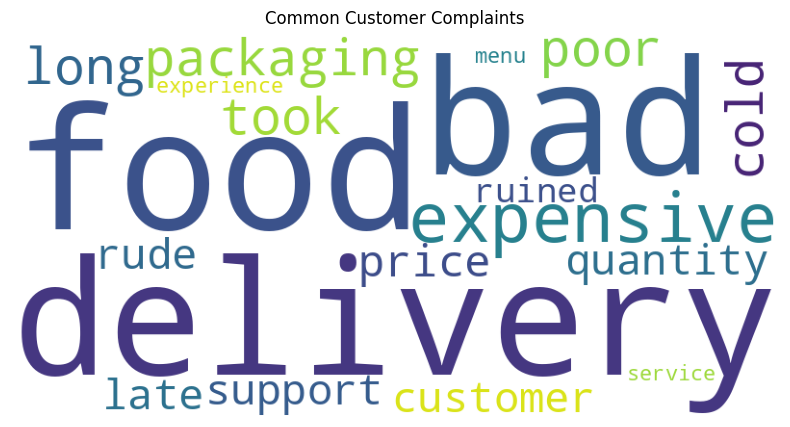

In [13]:
negative_reviews = df[df['sentiment'] == 'Negative']

text = " ".join(negative_reviews['clean_review'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Common Customer Complaints")
plt.show()

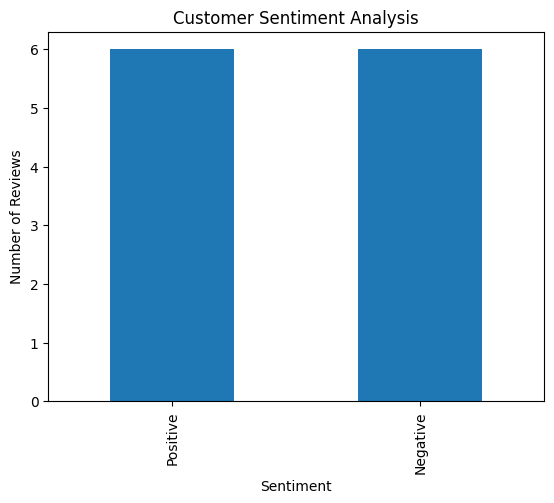

In [14]:
df['sentiment'].value_counts().plot(
    kind='bar'
)

plt.title("Customer Sentiment Analysis")

plt.xlabel("Sentiment")

plt.ylabel("Number of Reviews")

plt.show()

In [15]:
from collections import Counter

all_words = text.split()

common_words = Counter(all_words)

print(common_words.most_common(10))

[('food', 2), ('delivery', 2), ('bad', 2), ('expensive', 2), ('packaging', 1), ('poor', 1), ('cold', 1), ('took', 1), ('long', 1), ('price', 1)]


In [16]:
total_reviews = len(df)

positive = len(df[df['sentiment']=="Positive"])

negative = len(df[df['sentiment']=="Negative"])


print("\n----- RESTAURANT FEEDBACK REPORT -----")

print("Total Reviews:", total_reviews)

print("Positive Reviews:", positive)

print("Negative Reviews:", negative)

print("Customer Satisfaction Rate:",
      (positive/total_reviews)*100,"%")

print("\nMain Issues Found:")

for word,count in common_words.most_common(5):
    print(word, ":", count)


----- RESTAURANT FEEDBACK REPORT -----
Total Reviews: 12
Positive Reviews: 6
Negative Reviews: 6
Customer Satisfaction Rate: 50.0 %

Main Issues Found:
food : 2
delivery : 2
bad : 2
expensive : 2
packaging : 1
